In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [36]:
r=df.pivot_table(index="type",values="cast",aggfunc=["count"])
r


,count
,cast
type,
Movie,5377
TV Show,2410


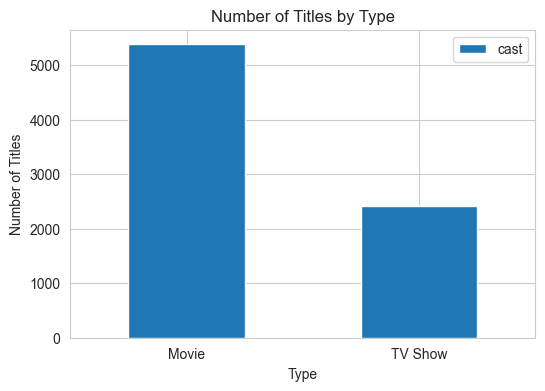

In [ ]:
# Graph for number of Movie vs TV Show
r["count"].plot(kind="bar", figsize=(6,4))
plt.title("Number of Titles by Type")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

In [9]:
x=df.pivot_table(index="release_year",columns="type",values="title",aggfunc="count")
x

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,NaN
...,...,...
2017,744.0,268.0
2018,734.0,387.0
2019,582.0,414.0


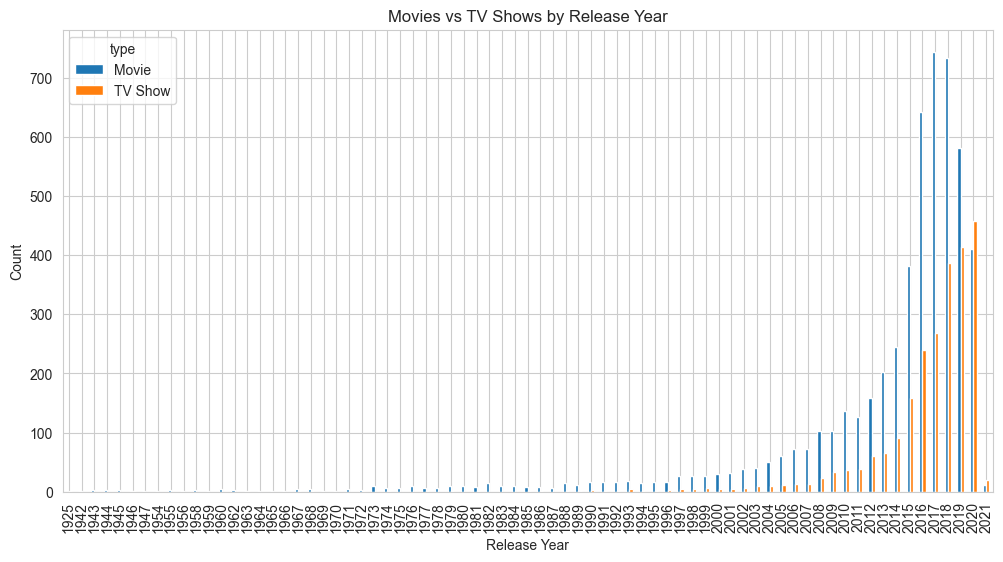

In [ ]:
# Graph for number of Movies and TV Shows streamed each year.
x.plot(kind="bar", figsize=(12,6))
plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [7]:
y=df.pivot_table(index='type',columns='release_year',values='date_added',aggfunc=["count"])
y

count                                               ...         \
release_year  1925 1942 1943 1944 1945 1946 1947 1954 1955 1956  ...   2012   
type                                                             ...          
Movie          NaN  2.0  3.0  3.0  3.0  1.0  1.0  2.0  3.0  2.0  ...  158.0   
TV Show        1.0  NaN  NaN  NaN  NaN  1.0  NaN  NaN  NaN  NaN  ...   61.0   

                                                                            
release_year   2013   2014   2015   2016   2017   2018   2019   2020  2021  
type                                                                        
Movie         202.0  244.0  382.0  642.0  744.0  734.0  582.0  411.0  12.0  
TV Show        65.0   90.0  159.0  240.0  268.0  387.0  414.0  457.0  19.0  

[2 rows x 73 columns]

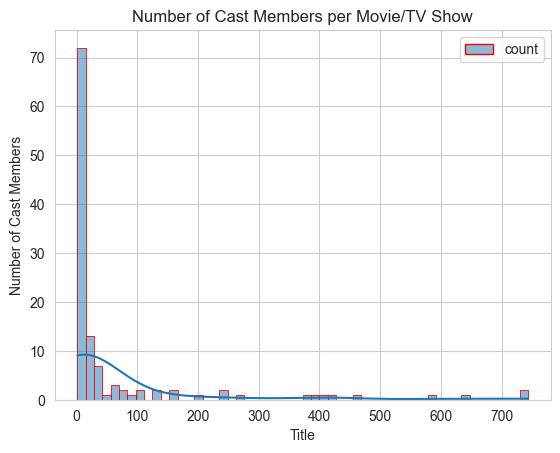

In [ ]:
# Graph for count of cast members in movies and tv shows
sns.set_style("whitegrid")
sns.histplot(y,kde=True,color="blue",edgecolor="red")
plt.xlabel("Title")
plt.ylabel("Number of Cast Members")
plt.title("Number of Cast Members per Movie/TV Show")
plt.show()

In [13]:
q=df.pivot_table(index="rating",columns="type",values="title",aggfunc="count")
q

type,Movie,TV Show
rating,,
G,39.0,NaN
NC-17,3.0,NaN
NR,79.0,5.0
PG,247.0,NaN
PG-13,386.0,NaN
R,663.0,2.0
TV-14,1272.0,659.0
TV-G,111.0,83.0
TV-MA,1850.0,1020.0


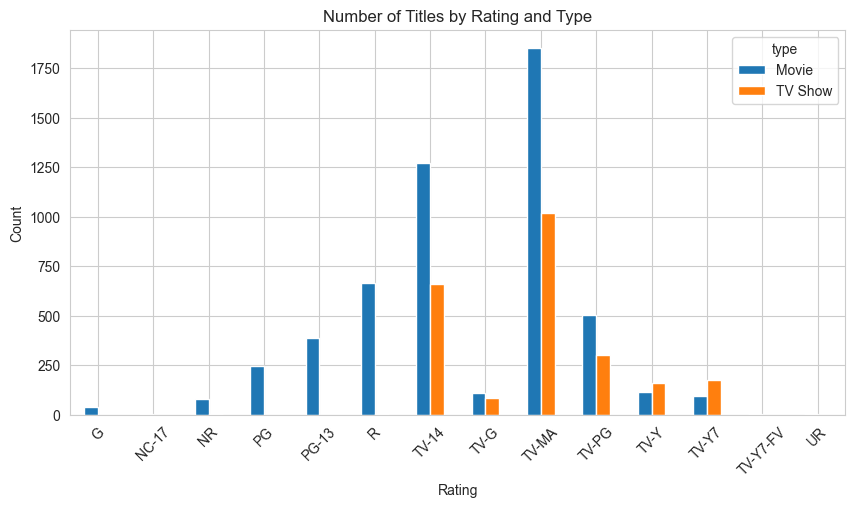

In [ ]:
#Graph for number of Titles by rating and type.
q.plot(kind="bar", figsize=(10,5))
plt.title("Number of Titles by Rating and Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

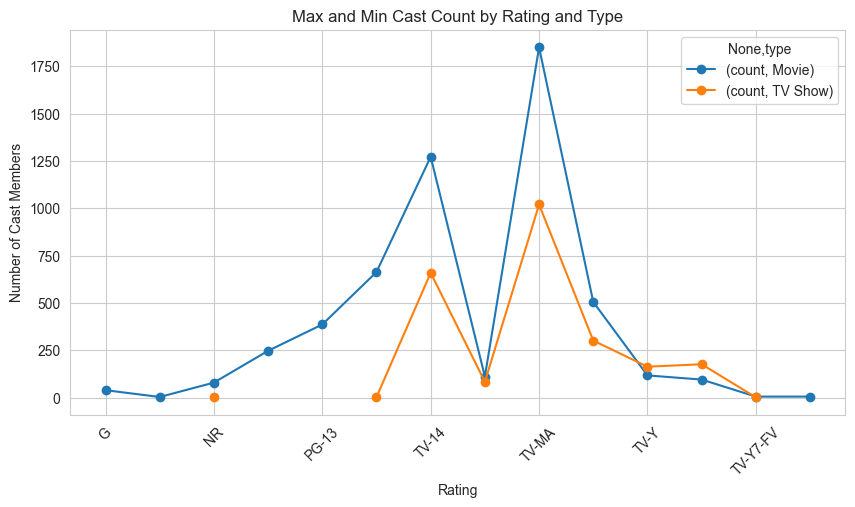

In [15]:
e=df.pivot_table(index="rating",columns="type",values="cast",aggfunc=["count"])
e
e.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Max and Min Cast Count by Rating and Type")
plt.xlabel("Rating")
plt.ylabel("Number of Cast Members")
plt.xticks(rotation=45)
plt.show()

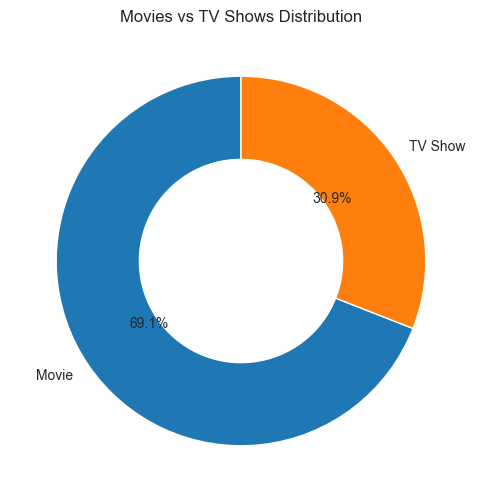

In [ ]:
counts = df['type'].value_counts()
# Donut graph to show the percentage of movies and TV shows
plt.figure(figsize=(6,6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.45}   # donut style
)

plt.title("Movies vs TV Shows Distribution")

plt.show()

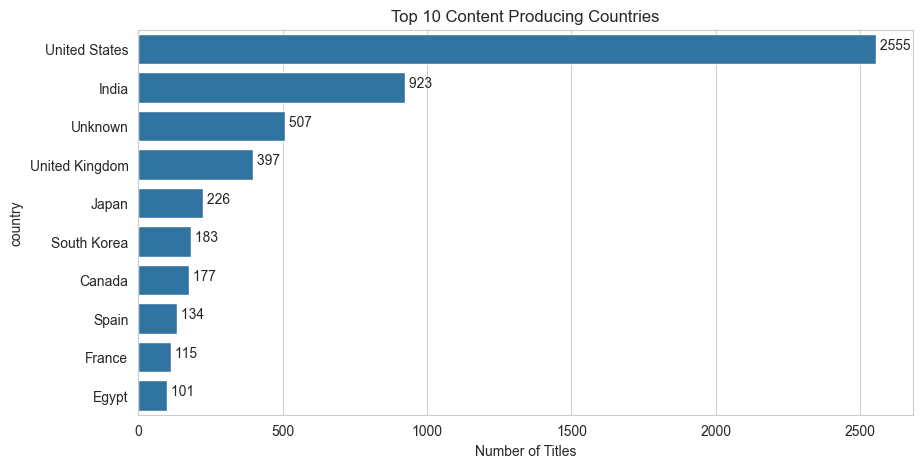

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().sort_index()
top_country = df['country'].value_counts().head(10)

# Top content producing countries
plt.figure(figsize=(10,5))

ax = sns.barplot(x=top_country.values, y=top_country.index)

for i, v in enumerate(top_country.values):
    ax.text(v, i, f" {v}")

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")

plt.show()

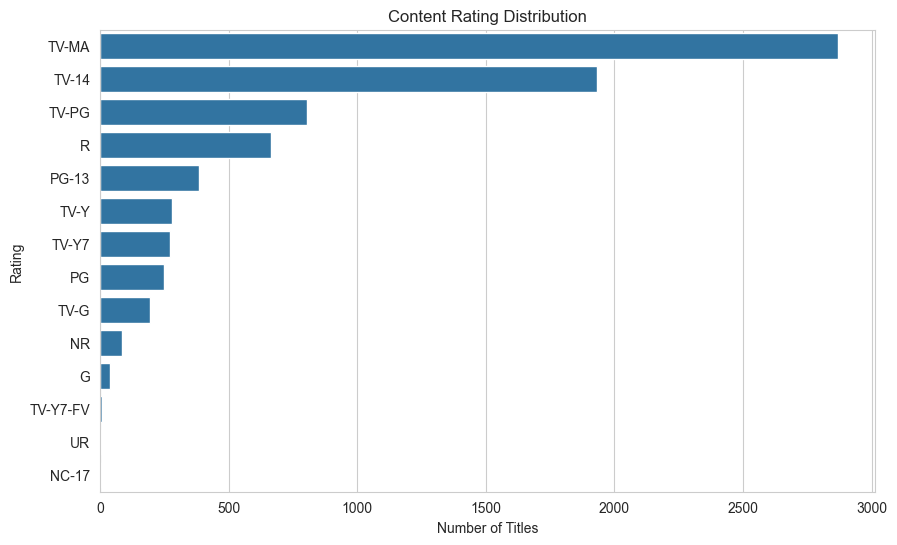

In [ ]:
# Number of contents rated
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='rating',
    order=rating_counts.index
)

plt.title("Content Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

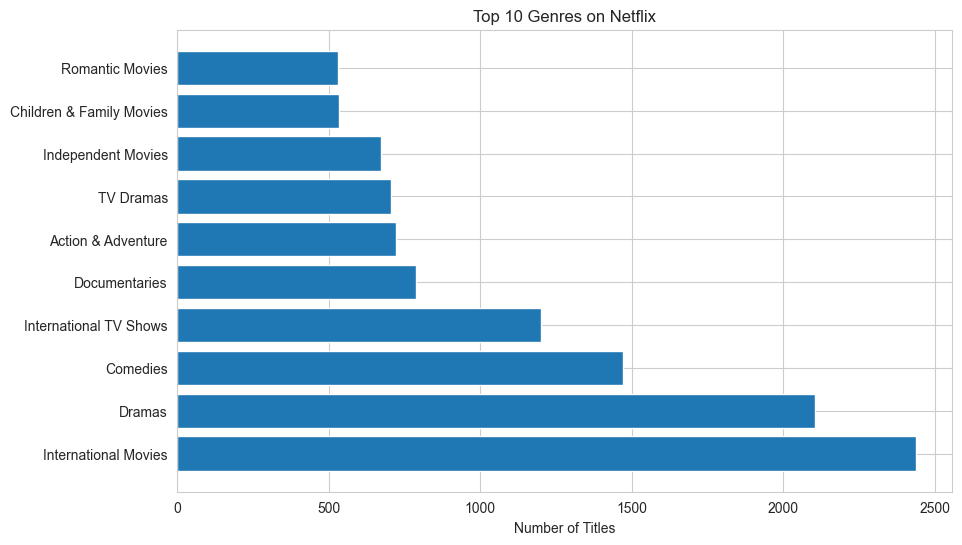

In [ ]:
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)

# Top Genres
plt.figure(figsize=(10,6))

plt.barh(top_genres.index, top_genres.values)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")

plt.show()

In [34]:
grouped = df.groupby(['type', 'year_added']).size()
data= grouped.reset_index(name='count')

data = (
    df.groupby(['type', 'year_added'])
      .size()
      .reset_index(name="count")
)

data

,type,year_added,count
0,Movie,2008.0,1
1,Movie,2009.0,2
2,Movie,2010.0,1
3,Movie,2011.0,13
4,Movie,2012.0,3
5,Movie,2013.0,6
6,Movie,2014.0,19
7,Movie,2015.0,58
8,Movie,2016.0,258
9,Movie,2017.0,864


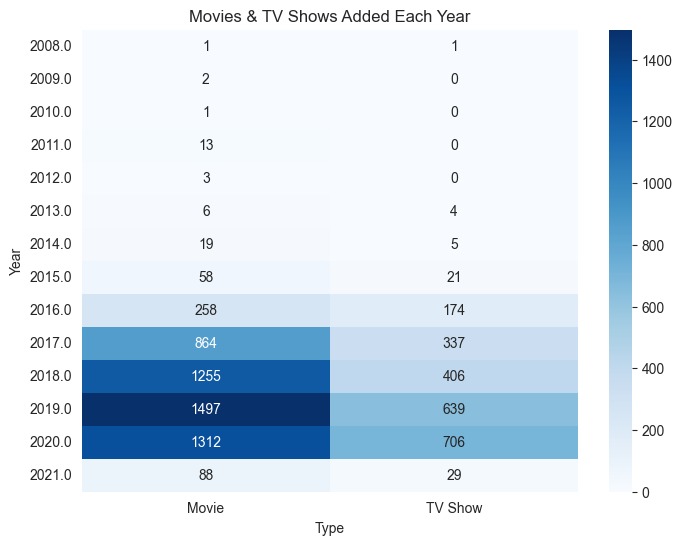

In [32]:
grouped = df.groupby(['year_added', 'type']).size()
pivot = grouped.unstack()
pivot = pivot.fillna(0)

pivot.head()
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title("Movies & TV Shows Added Each Year")
plt.xlabel("Type")
plt.ylabel("Year")

plt.show()

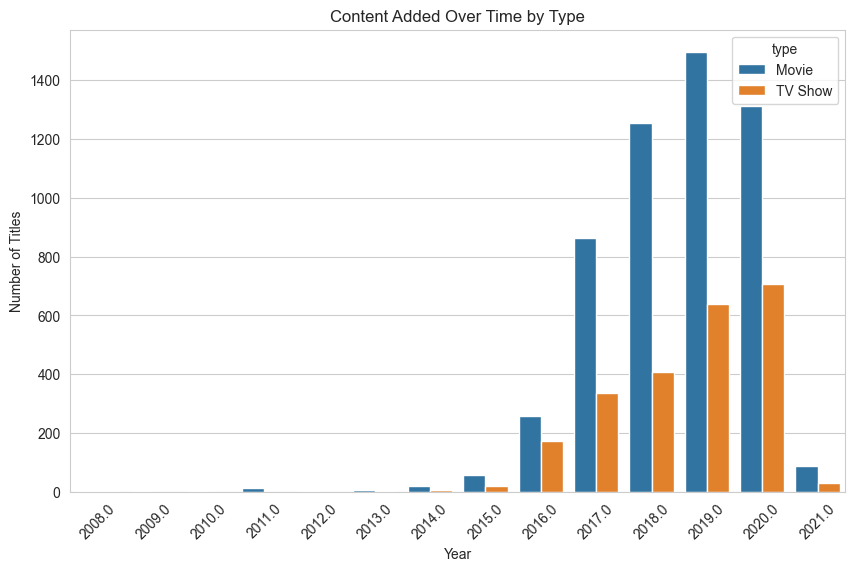

In [ ]:
bar_data = grouped.reset_index(name='count')
bar_data.head()

plt.figure(figsize=(10,6))

sns.barplot(
    data=bar_data,
    x='year_added',
    y='count',
    hue='type'
)

plt.title("Content Added Over Time by Type")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()